# QQQ Drawdown Detection - Labels and Analysis
------------------------------------------

### Import the modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Modules are imported.')

Modules are imported.


### Load the clean dataset

In [2]:
print("Cargando datos...")
df = pd.read_csv('Data/QQQ_features_clean_2014_2024.csv', index_col=0, parse_dates=True)

print(f"Datos cargados: {len(df)} registros")
print(f"Período: {df.index.min()} a {df.index.max()}")

Cargando datos...
Datos cargados: 2568 registros
Período: 2014-10-16 00:00:00 a 2024-12-30 00:00:00


### Calculate Drawdown (percentage from peak)

In [3]:
# Calcular el drawdown (% desde el máximo histórico)
df['Cumulative_Max'] = df['Close'].cummax()
df['Drawdown'] = ((df['Close'] - df['Cumulative_Max']) / df['Cumulative_Max']) * 100

print("✓ Drawdown calculado")
print(f"Drawdown máximo histórico: {df['Drawdown'].min():.2f}%")

✓ Drawdown calculado
Drawdown máximo histórico: -35.12%


### Label drawdown periods (>10%)

In [4]:
print("\n" + "="*60)
print("ETIQUETANDO DRAWDOWNS >10%")
print("="*60 + "\n")

# Etiqueta binaria: 1 = en drawdown >10%, 0 = no
df['Drawdown_30d'] = (df['Drawdown'] <= -10).astype(int)

drawdown_events = df['Drawdown_30d'].sum()
pct_drawdown_days = (drawdown_events / len(df)) * 100

print(f"📉 Días en drawdown >10%: {drawdown_events} ({pct_drawdown_days:.2f}%)")
print(f"📊 Drawdown máximo: {df['Drawdown'].min():.2f}%")
print(f"📊 Drawdown promedio: {df['Drawdown'].mean():.2f}%")


ETIQUETANDO DRAWDOWNS >10%

📉 Días en drawdown >10%: 512 (19.94%)
📊 Drawdown máximo: -35.12%
📊 Drawdown promedio: -6.14%


### Identify individual drawdown events

In [5]:
# Identificar eventos individuales de drawdown
df['Drawdown_Group'] = (df['Drawdown_30d'] != df['Drawdown_30d'].shift()).cumsum()
df['Drawdown_Group'] = df['Drawdown_Group'].where(df['Drawdown_30d'] == 1, 0)

# Analizar cada evento de drawdown
drawdown_periods = df[df['Drawdown_30d'] == 1].groupby('Drawdown_Group').agg({
    'Close': ['first', 'last', 'min'],
    'Drawdown': 'min'
})

drawdown_periods.columns = ['Start_Price', 'End_Price', 'Min_Price', 'Max_Drawdown']
drawdown_periods = drawdown_periods[drawdown_periods.index != 0]  # Eliminar grupo 0

# Calcular duración de cada evento
drawdown_periods['Duration'] = df[df['Drawdown_30d'] == 1].groupby('Drawdown_Group').size()
drawdown_periods = drawdown_periods.dropna()

print(f"\n🔴 Número de eventos de drawdown >10%: {len(drawdown_periods)}")


🔴 Número de eventos de drawdown >10%: 45


### Display top 10 drawdown events

In [6]:
print("\nPrincipales eventos de drawdown:")
print(drawdown_periods.sort_values('Max_Drawdown').head(10))


Principales eventos de drawdown:
                Start_Price   End_Price   Min_Price  Max_Drawdown  Duration
Drawdown_Group                                                             
70               352.999268  349.210052  255.594299    -35.118732       297
42               204.433502  202.777802  163.573898    -28.559354        29
34               158.353210  158.767899  137.513245    -22.796659        38
66               349.956543  351.288574  310.648285    -21.143567        31
16                95.131737   95.504280   89.702301    -16.104406        16
62               353.168762  354.467316  333.036255    -15.460499         8
32               160.054031  156.174545  152.084793    -14.615831         7
2                 94.843460   90.851524   90.851524    -13.941034         3
86               346.085754  352.625336  339.486877    -13.823042         6
88               445.714813  448.326996  431.829315    -13.557746         7


### Save dataset with drawdown labels

In [7]:
df.to_csv('Data/QQQ_features_with_drawdowns.csv', index=True)
print("\n✅ Dataset guardado: Data/QQQ_features_with_drawdowns.csv")


✅ Dataset guardado: Data/QQQ_features_with_drawdowns.csv


### Exploratory Data Analysis - Descriptive Statistics

In [8]:
print("\n" + "="*60)
print("ANÁLISIS EXPLORATORIO DE DATOS")
print("="*60 + "\n")

features = ['VIX', 'RSI_14d', 'MACD', 'Historical_Vol_30d', 
            'Bollinger_Band_Width', 'ATR_14d', 'Distance_to_MA200', 
            'Volume_Ratio', 'SPY_QQQ_Correlation', 'Return_20d']

print("ESTADÍSTICAS DESCRIPTIVAS DE FEATURES:")
df[features].describe()


ANÁLISIS EXPLORATORIO DE DATOS

ESTADÍSTICAS DESCRIPTIVAS DE FEATURES:


,VIX,RSI_14d,MACD,Historical_Vol_30d,Bollinger_Band_Width,ATR_14d,Distance_to_MA200,Volume_Ratio,SPY_QQQ_Correlation,Return_20d
count,2568.000000,2568.000000,2568.000000,2568.000000,2568.000000,2568.000000,2568.000000,2568.000000,2568.000000,2568.000000
mean,18.211441,56.206082,1.155281,0.193555,0.080426,3.913862,7.017937,1.008446,0.911482,1.525471
std,7.232303,11.579505,3.501509,0.100276,0.042671,2.583113,8.665664,0.375083,0.057449,5.310877
min,9.140000,19.149665,-12.517747,0.053877,0.011616,0.747933,-23.706906,0.242889,0.676524,-27.846898
25%,13.340000,47.945691,-0.236920,0.128351,0.049568,1.456976,3.549396,0.766075,0.885237,-1.146837
50%,16.265000,57.186480,1.106189,0.167031,0.071965,3.508180,8.450618,0.934195,0.928029,2.077836
75%,21.255000,64.589481,3.055786,0.243620,0.099592,5.732788,11.949749,1.168215,0.955389,4.811693
max,82.690002,85.587712,10.178226,0.815375,0.347502,11.406842,33.084283,3.867169,0.991124,25.405479


### Visualization 1: Features Distribution Histograms

📊 Gráfico guardado: features_distributions.png


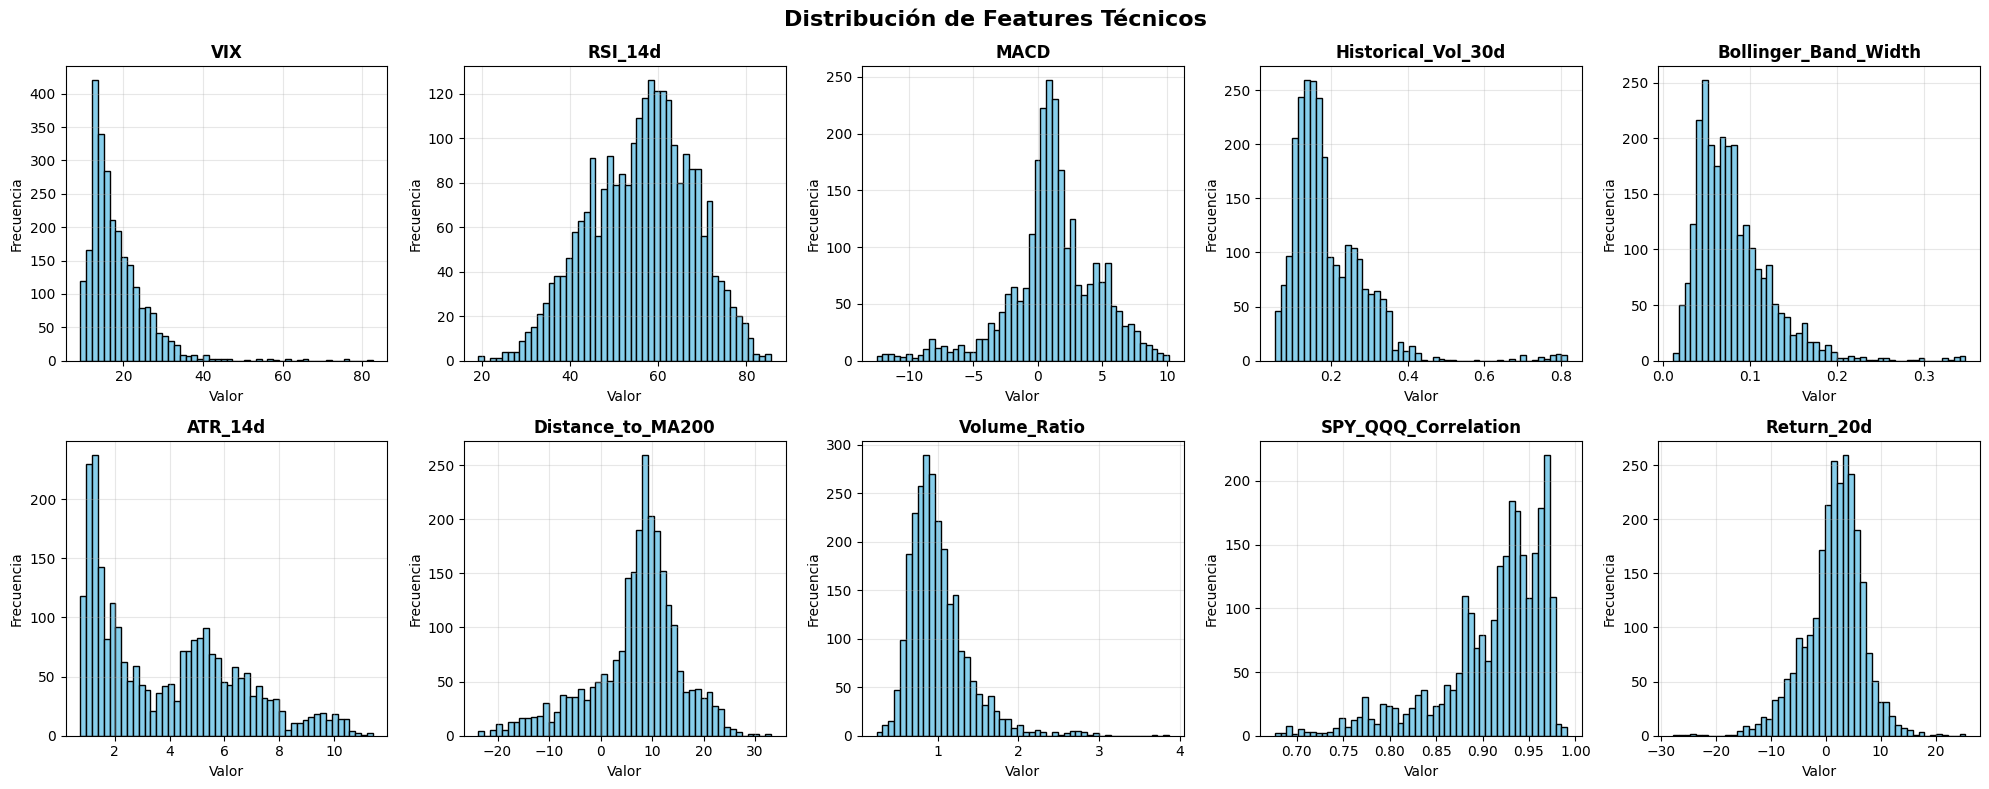

In [9]:
# Distribuciones de features
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

for idx, feature in enumerate(features):
    axes[idx].hist(df[feature].dropna(), bins=50, color='skyblue', edgecolor='black')
    axes[idx].set_title(feature, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Valor')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Distribución de Features Técnicos', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('features_distributions.png', dpi=300, bbox_inches='tight')
print("📊 Gráfico guardado: features_distributions.png")
plt.show()

### Visualization 2: Correlation Matrix

📊 Gráfico guardado: correlation_matrix.png


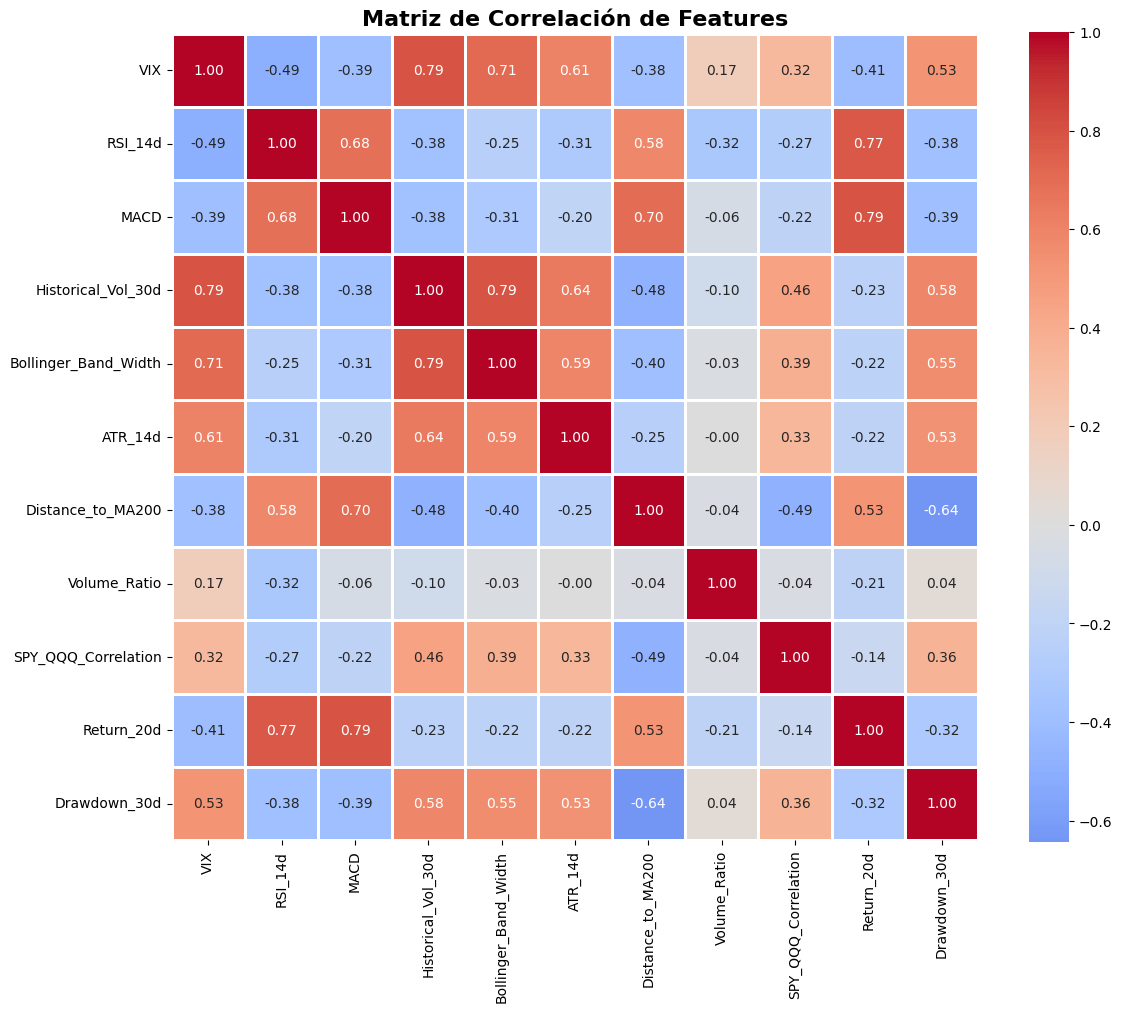

In [10]:
# Matriz de correlación
correlation_matrix = df[features + ['Drawdown_30d']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1)
plt.title('Matriz de Correlación de Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
print("📊 Gráfico guardado: correlation_matrix.png")
plt.show()

### Visualization 3: QQQ Price and Drawdown Timeline

📊 Gráfico guardado: qqq_price_drawdowns.png


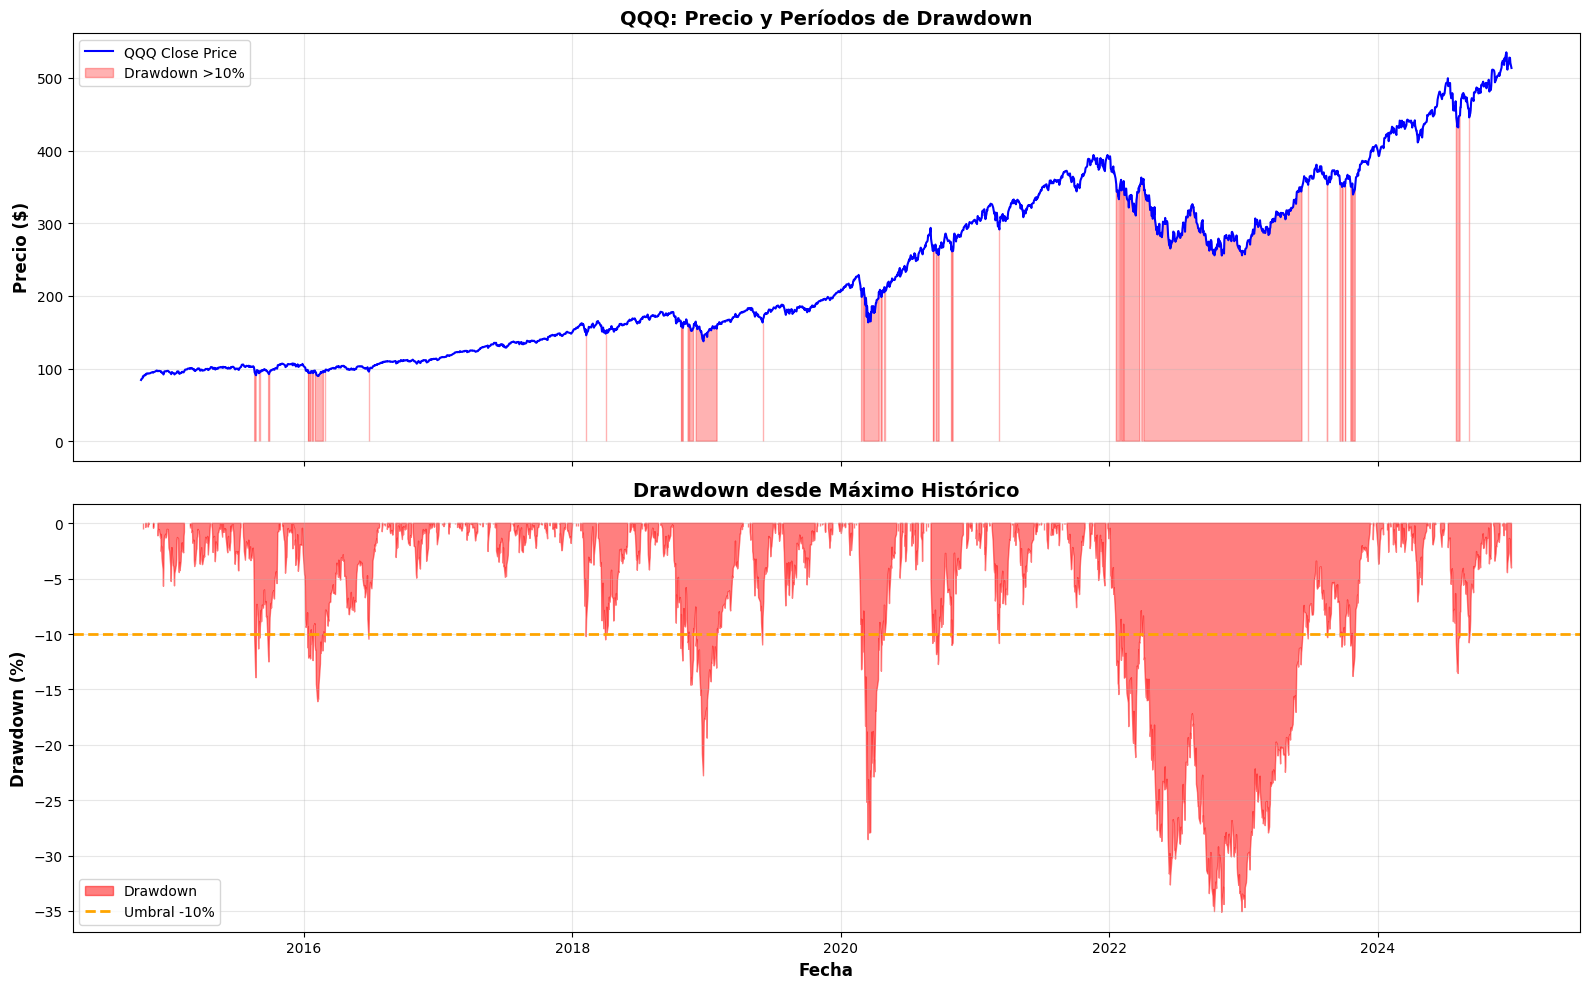

In [11]:
# Gráfico de precio y drawdown
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Subplot 1: Precio de QQQ
ax1.plot(df.index, df['Close'], label='QQQ Close Price', color='blue', linewidth=1.5)
ax1.fill_between(df.index, df['Close'], 
                  where=df['Drawdown_30d']==1, 
                  color='red', alpha=0.3, label='Drawdown >10%')
ax1.set_ylabel('Precio ($)', fontsize=12, fontweight='bold')
ax1.set_title('QQQ: Precio y Períodos de Drawdown', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Subplot 2: Drawdown
ax2.fill_between(df.index, df['Drawdown'], 0, 
                  where=df['Drawdown']<0, 
                  color='red', alpha=0.5, label='Drawdown')
ax2.axhline(y=-10, color='orange', linestyle='--', linewidth=2, label='Umbral -10%')
ax2.set_xlabel('Fecha', fontsize=12, fontweight='bold')
ax2.set_ylabel('Drawdown (%)', fontsize=12, fontweight='bold')
ax2.set_title('Drawdown desde Máximo Histórico', fontsize=14, fontweight='bold')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('qqq_price_drawdowns.png', dpi=300, bbox_inches='tight')
print("📊 Gráfico guardado: qqq_price_drawdowns.png")
plt.show()

### Visualization 4: Feature Comparison (Normal vs Drawdown)

C:\Users\PC-Francisco\AppData\Local\Temp\ipykernel_27164\413743810.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot([normal_data, drawdown_data],
C:\Users\PC-Francisco\AppData\Local\Temp\ipykernel_27164\413743810.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot([normal_data, drawdown_data],
C:\Users\PC-Francisco\AppData\Local\Temp\ipykernel_27164\413743810.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[idx].boxplot([normal_data, drawdown_data],
C:\Users\PC-Francisco\AppData\Local\Temp\ipykernel_27164\413743810.py:11: MatplotlibDeprecationWarning: The 'labels' para

📊 Gráfico guardado: features_comparison_drawdown.png


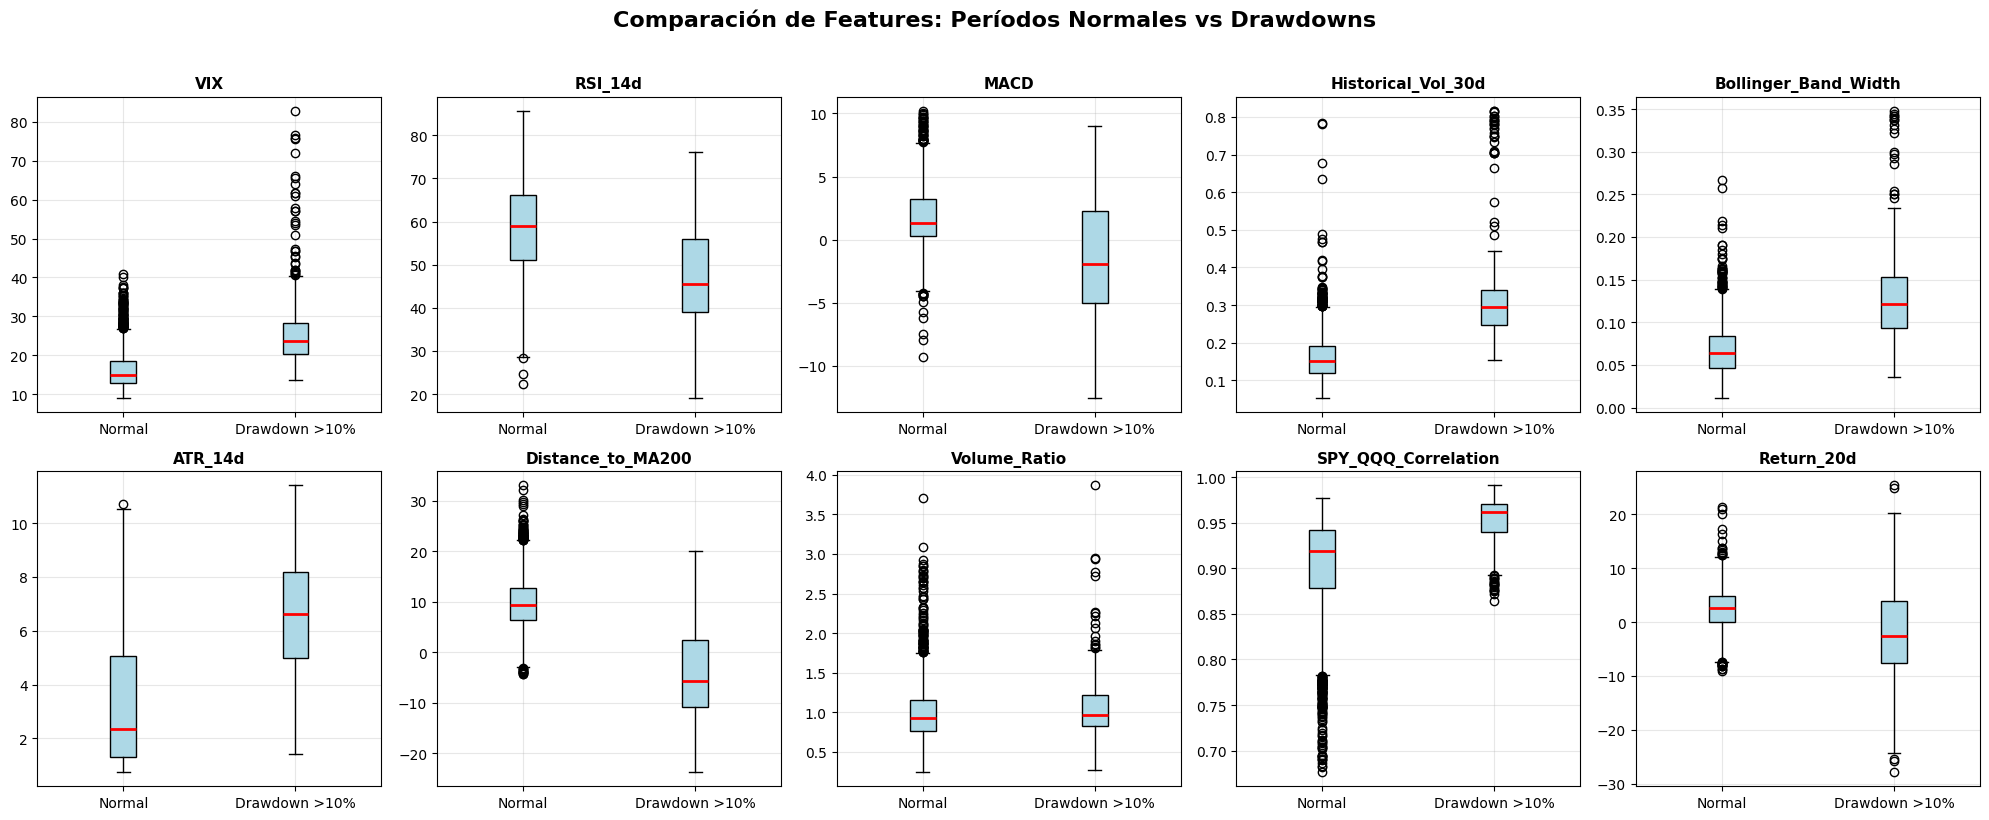

In [12]:
# Comparación de features en drawdown vs no-drawdown
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

for idx, feature in enumerate(features):
    # Separar datos por drawdown
    drawdown_data = df[df['Drawdown_30d'] == 1][feature].dropna()
    normal_data = df[df['Drawdown_30d'] == 0][feature].dropna()
    
    # Boxplot
    axes[idx].boxplot([normal_data, drawdown_data], 
                       labels=['Normal', 'Drawdown >10%'],
                       patch_artist=True,
                       boxprops=dict(facecolor='lightblue'),
                       medianprops=dict(color='red', linewidth=2))
    axes[idx].set_title(feature, fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Comparación de Features: Períodos Normales vs Drawdowns', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('features_comparison_drawdown.png', dpi=300, bbox_inches='tight')
print("📊 Gráfico guardado: features_comparison_drawdown.png")
plt.show()

### Final Summary

In [13]:
print("\n" + "="*60)
print("RESUMEN FINAL")
print("="*60)
print(f"✅ Total de registros analizados: {len(df)}")
print(f"✅ Días en drawdown >10%: {drawdown_events} ({pct_drawdown_days:.2f}%)")
print(f"✅ Eventos de drawdown identificados: {len(drawdown_periods)}")
print(f"✅ Features calculados: {len(features)}")
print(f"\nArchivos generados:")
print(f"  - Data/QQQ_features_with_drawdowns.csv")
print(f"  - features_distributions.png")
print(f"  - correlation_matrix.png")
print(f"  - qqq_price_drawdowns.png")
print(f"  - features_comparison_drawdown.png")
print("\n🎯 Análisis completado exitosamente!")


RESUMEN FINAL
✅ Total de registros analizados: 2568
✅ Días en drawdown >10%: 512 (19.94%)
✅ Eventos de drawdown identificados: 45
✅ Features calculados: 10

Archivos generados:
  - Data/QQQ_features_with_drawdowns.csv
  - features_distributions.png
  - correlation_matrix.png
  - qqq_price_drawdowns.png
  - features_comparison_drawdown.png

🎯 Análisis completado exitosamente!
